In [181]:
import os
import sys
import gtfparse
from matplotlib.backend_bases import NonGuiException
import numpy as np
import pandas as pd
from pathlib import Path
import logging
import json
import muon as mu
from sklearn.metrics import roc_auc_score

import torch
import argparse

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER")
sys.path.append(str(PROJECT_DIR))

DATA_DIR = PROJECT_DIR.parent / "data"

import utils
from utils import prepare_tftg_lookup_tables, build_tftg_inputs

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

def _format_chroms(chroms: list[str]) -> str:
    """Render a chromosome list for logging.

    Only for log messages -- the splits themselves are made with isin() on the full list.
    min()/max() would compare these as strings, where "9" > "15", so ["1".."15"] printed
    as "1-15" came out as "1-9". Numeric labels are ordered numerically and collapsed to
    a range only when they are actually contiguous.
    """
    numeric = sorted((c for c in chroms if str(c).isdigit()), key=int)
    other = sorted(str(c) for c in chroms if not str(c).isdigit())

    parts = []
    if numeric:
        contiguous = int(numeric[-1]) - int(numeric[0]) == len(numeric) - 1
        parts.append(f"{numeric[0]}-{numeric[-1]}" if contiguous and len(numeric) > 1
                     else ", ".join(numeric))
    parts.extend(other)
    return ", ".join(parts)


def split_genes_by_chromosome(
    gene_reference_file: Path,
    train_chroms: list[str] = None,
    val_chroms: list[str] = None,
    test_chroms: list[str] = None
    ):
    logging.info(f"Splitting genes into train/val/test based on chromosome:")
    gene_ref_df = gtfparse.read_gtf(gene_reference_file, result_type="pandas")

    gene_chrom: pd.DataFrame = gene_ref_df[["seqname", "gene_name"]].rename(
        columns={"seqname": "chrom", "gene_name": "TG"}
    )
    
    gene_chrom["chrom"] = gene_chrom["chrom"].astype(str).str.replace("^chr", "", regex=True)
    gene_chrom["TG"] = gene_chrom["TG"].str.upper()
    
    train_genes = gene_chrom[gene_chrom["chrom"].isin(train_chroms)][
        "TG"
    ].unique()
    logging.info(f"  - Train set: {len(train_genes):,} genes (chroms {_format_chroms(train_chroms)})")

    val_genes = gene_chrom[gene_chrom["chrom"].isin(val_chroms)][
        "TG"
    ].unique()
    logging.info(f"  - Validation set: {len(val_genes):,} genes (chroms {_format_chroms(val_chroms)})")

    test_genes = gene_chrom[gene_chrom["chrom"].isin(test_chroms)]["TG"].unique()
    logging.info(f"  - Test set: {len(test_genes):,} genes (chroms {_format_chroms(test_chroms)})")

    return train_genes, val_genes, test_genes


def create_degree_matched_edges(edge_df, tf_col="Source", item_col="Target",
                                seed=123, max_partners=32):
    """Negatives that preserve BOTH the TF out-degree and the TG in-degree.

    Pairs of GT edges (t1,g1),(t2,g2) whose crossed pairs (t1,g2),(t2,g1) are both
    non-edges contribute two positives and two negatives. Each of t1, t2, g1, g2 then
    gains exactly one positive and one negative, so per-TF and per-TG label rates are
    0.5 by construction and neither identity predicts the label.

    A rectangle is all-or-nothing. Accepting one whose positives were already used
    would add two negatives and fewer than two positives, which is what breaks the
    balance -- so every one of the four pairs must be unused.

    Each GT edge is consumed at most once, so this walks a shuffled edge list and
    looks for a partner, rather than sampling random pairs and rejecting: as the
    unused pool shrinks, random pairing almost always collides.
    """
    rng = np.random.default_rng(seed)

    df = (edge_df[[tf_col, item_col]].dropna().astype(str)
          .drop_duplicates().reset_index(drop=True))
    gt = set(zip(df[tf_col], df[item_col]))

    pool = list(gt)
    rng.shuffle(pool)
    available = set(pool)

    true_edges, false_edges = set(), set()

    for edge in pool:
        if edge not in available:
            continue
        t1, g1 = edge

        partners = rng.choice(len(pool), size=min(max_partners, len(pool)), replace=False)
        for p in partners:
            other = pool[p]
            if other not in available or other == edge:
                continue
            t2, g2 = other
            if t1 == t2 or g1 == g2:
                continue
            if (t1, g2) in gt or (t2, g1) in gt:
                continue
            if (t1, g2) in false_edges or (t2, g1) in false_edges:
                continue

            true_edges |= {edge, other}
            false_edges |= {(t1, g2), (t2, g1)}
            available.discard(edge)
            available.discard(other)
            break

    logging.info(
        f"Degree-matched sampling: {len(true_edges):,} positive, {len(false_edges):,} "
        f"negative ({len(true_edges) / max(len(gt), 1):.1%} of the GT used)"
    )
    return true_edges, false_edges



def create_train_val_test_splits(
    tf_tg_labeled_df: pd.DataFrame,
    train_genes: np.ndarray,
    val_genes: np.ndarray,
    test_genes: np.ndarray,
):
    train_genes_set = set(train_genes)
    val_genes_set = set(val_genes)
    test_genes_set = set(test_genes)

    # Subset the ground truth to create train/val/test splits based on the target gene chromosome splits
    gt_train_df = tf_tg_labeled_df[tf_tg_labeled_df["tg_id"].isin(train_genes_set)].copy()
    gt_val_df = tf_tg_labeled_df[tf_tg_labeled_df["tg_id"].isin(val_genes_set)].copy()
    gt_test_df = tf_tg_labeled_df[tf_tg_labeled_df["tg_id"].isin(test_genes_set)].copy()
    
    if len(gt_train_df) == 0:
        logging.warning("No training interactions found for the selected train genes.")
        logging.info(f"Dataset genes: {list(train_genes_set)[:5]}")
        logging.info(f"Ground truth target genes: {tf_tg_labeled_df['tg_id'].unique()[:5]}")

    return gt_train_df, gt_val_df, gt_test_df


def create_true_false_edges_from_full_universe(
    edge_df: pd.DataFrame,
    tf_col: str = "Source",
    item_col: str = "Target",
    pct_true_edges: float | None = 1.0,
    true_false_ratio: float = 1.0,
    seed: int = 123,
):
    df_all = edge_df[[tf_col, item_col]].copy()

    df_all = df_all.dropna(subset=[tf_col, item_col])

    df_all[tf_col] = df_all[tf_col].astype(str)
    df_all[item_col] = df_all[item_col].astype(str)

    df_all = df_all.drop_duplicates([tf_col, item_col]).reset_index(drop=True)

    if df_all.empty:
        raise ValueError(
            f"No edges remain after filtering by tf_names using columns "
            f"{tf_col!r} and {item_col!r}."
        )

    candidate_tfs = sorted(df_all[tf_col].unique())
    candidate_items = sorted(df_all[item_col].unique())

    gt_pairs = set(zip(df_all[tf_col], df_all[item_col]))

    full_universe = (
        pd.MultiIndex
        .from_product([candidate_tfs, candidate_items], names=[tf_col, item_col])
        .to_frame(index=False)
    )

    full_universe["_pair"] = list(zip(full_universe[tf_col], full_universe[item_col]))
    full_universe["_in_gt"] = full_universe["_pair"].isin(gt_pairs)

    true_df = full_universe[full_universe["_in_gt"]].copy()
    false_df = full_universe[~full_universe["_in_gt"]].copy()

    if pct_true_edges is not None:
        if not (0 < pct_true_edges <= 1):
            raise ValueError("pct_true_edges must be in (0, 1] or None.")

        true_df = true_df.sample(frac=pct_true_edges, random_state=seed)

    n_false = round(len(true_df) * true_false_ratio)

    if n_false > len(false_df):
        logging.warning(
            f"Requested {n_false:,} false edges, but only {len(false_df):,} are available. "
            "Using all available false edges."
        )
        n_false = len(false_df)

    false_df = false_df.sample(n=n_false, random_state=seed)

    true_edges = set(zip(true_df[tf_col], true_df[item_col]))
    false_edges = set(zip(false_df[tf_col], false_df[item_col]))

    return true_edges, false_edges


def create_labeled_tf_tg_dataset(
    true_interactions: set[tuple[str, str]],
    false_interactions: set[tuple[str, str]],
    tf_name_to_idx: dict[str, int],
    drop_missing: bool = True,
) -> pd.DataFrame:
    # sorted(), not bare set iteration: set order over string tuples depends on
    # PYTHONHASHSEED, so without this the col order -- and therefore anything
    # downstream that indexes by position, e.g. df.sample(n=...) -- differs in every
    # process even with a fixed random_state.
    rows = []
    for tf, tg in sorted(true_interactions):
        rows.append((tf, tg, 1))
    for tf, tg in sorted(false_interactions):
        rows.append((tf, tg, 0))

    df = pd.DataFrame(rows, columns=["tf_name", "tg_id", "label"])
    df["tf_embedding_idx"] = df["tf_name"].map(tf_name_to_idx)

    missing_mask = df["tf_embedding_idx"].isna()
    if missing_mask.any():
        n_missing = missing_mask.sum()
        if drop_missing:
            logging.info(f"Dropping {n_missing} interactions with missing TF or TG indices.")
            df = df.loc[~missing_mask].copy()
        else:
            missing_examples = df.loc[missing_mask].head()
            raise ValueError(
                f"{n_missing} interactions are missing TF or TG indices.\n"
                f"Examples:\n{missing_examples}"
            )

    df["tf_embedding_idx"] = df["tf_embedding_idx"].astype(np.int64)
    df["label"] = df["label"].astype(np.bool)

    return df.sample(frac=1.0, random_state=123).reset_index(drop=True)


def _create_labeled_df(
    gt_df: pd.DataFrame,
    seed: int = 123,
    *,
    tf_name_to_idx,
    tg_id_to_idx,
):
    """
    Creates a labeled DataFrame of TF-TG interactions from a ground truth DataFrame.
    
    Filters to only include TFs and TGs that are present in the provided index mappings, 
    then creates true and false edges based on randomly selecting from the full universe of possible edges.
    """
    
    gt_df = gt_df[
        gt_df["Source"].isin(tf_name_to_idx.keys()) &
        gt_df["Target"].isin(tg_id_to_idx.keys())
    ].copy()
    
    true_edges, false_edges = create_degree_matched_edges(
        edge_df=gt_df,
        tf_col="Source",
        item_col="Target",
        seed=seed,
    )

    return create_labeled_tf_tg_dataset(
        true_interactions=true_edges,
        false_interactions=false_edges,
        tf_name_to_idx=tf_name_to_idx,
        drop_missing=False,
    )


# -----------------------------------
# ARGUMENT HANDLING
# -----------------------------------
sample_names = ["E7.5_rep1"]
tissues = ["mESC"]
species = "mm10"
max_peaks_per_tg = 25
max_cells_per_pair = 64
pct_true_edges = 1
true_false_ratio = 2.0
peak_flank_size = 128
num_cpu = 4
force_reload = False
build_resample_matrices_only = False

# Only use peaks from standard chromosomes (chr1-chr19 for mm10, chr1-chr22 for hg38) to avoid issues with 
# non-standard chromosomes and contigs
if species == "mm10":
    valid_chroms = {f"chr{i}" for i in range(1, 20)}
    
    train_chroms = [str(i) for i in range(1, 16)]
    val_chroms = [ str(i) for i in range(16, 18)]
    test_chroms = [str(i) for i in range(18, 20)]
    
    gene_ref_file = DATA_DIR / "genome_data" / "genome_annotation" / "mm10" / "Mus_musculus.GRCm39.115.gtf.gz"
    
    
elif species == "hg38":
    valid_chroms = {f"chr{i}" for i in range(1, 23)}
    
    train_chroms = [str(i) for i in range(1, 18)]
    val_chroms = [str(i) for i in range(18, 20)]
    test_chroms = [str(i) for i in range(20, 23)]
    
    gene_ref_file = DATA_DIR / "genome_data" / "genome_annotation" / "hg38" / "Homo_sapiens.GRCh38.113.gtf.gz"

# Global cell type index map
cell_type_to_idx = {}

# Global TG index map
tg_id_to_idx = {}

labeled_dfs = []

cell_pools = {}

logging.info(f" === Species: {species} ===\n")

# Start of the per-sample for loop in the real dataset caching script
sample_name = sample_names[0]
tissue = tissues[0]

INFO:root: === Species: mm10 ===



### Locate genes on the train/val/test chromosomes

In [ ]:
# Split genes into train/val/test based on chromosome using the GTF reference file
train_genes, val_genes, test_genes = split_genes_by_chromosome(
    gene_ref_file,
    train_chroms=train_chroms,
    val_chroms=val_chroms,
    test_chroms=test_chroms
    )

### Set directories

In [183]:
logging.info(f" Building for Sample: {sample_name}, Tissue: {tissue}\n")
    
genome_fasta_path = DATA_DIR / "genome_data" / "reference_genome" / species / f"{species}.fa"
chrom_sizes_path = DATA_DIR / "genome_data" / "reference_genome" / species / f"{species}.chrom.sizes"

assert gene_ref_file.exists(), f"Gene reference file not found: {gene_ref_file}"
assert genome_fasta_path.exists(), f"Genome FASTA file not found: {genome_fasta_path}"
assert chrom_sizes_path.exists(), f"Chromosome sizes file not found: {chrom_sizes_path}"

input_data_dir = DATA_DIR / "processed" / tissue / sample_name
assert input_data_dir.exists(), f"Input data directory does not exist: {input_data_dir}"

training_cache_dir = PROJECT_DIR / "cached_data_cell_type_specific" / species / f"{tissue}_tf_tg_cache"
tf_dna_input_cache_dir = PROJECT_DIR / "cached_data" / species / "tf_dna_cache"
tf_tg_input_cache_dir = training_cache_dir / sample_name

tf_tg_input_cache_dir.mkdir(parents=True, exist_ok=True)

tf_name_to_idx_cache_path = tf_dna_input_cache_dir / "tf_name_to_idx.csv"
tf_embedding_cache_path = tf_dna_input_cache_dir / "tf_embeddings.pt"
tf_mask_cache_path = tf_dna_input_cache_dir / "tf_masks.pt"
        
atac_peak_onehot_cache_path = tf_tg_input_cache_dir / "atac_peak_tensor.pt"
train_file = tf_tg_input_cache_dir / "tftg_inputs_train.pt"
val_file = tf_tg_input_cache_dir / "tftg_inputs_val.pt"
test_file = tf_tg_input_cache_dir / "tftg_inputs_test.pt"

metadata_file = tf_tg_input_cache_dir / "metadata.json"
manifest_file = tf_tg_input_cache_dir / "manifest.json"

tss_file = DATA_DIR / "genome_data" / "genome_annotation" / species / f"{species}_gene_tss.bed"

required_cache_files = [
    tf_name_to_idx_cache_path,
    tf_embedding_cache_path,
    tf_mask_cache_path,
    atac_peak_onehot_cache_path,
    train_file,
    val_file,
    test_file,
    metadata_file,
    manifest_file,
]

cell_type_specific_gt_dir = DATA_DIR / "ground_truth_files" / "cell_type_specific"


INFO:root: Building for Sample: E7.5_rep1, Tissue: mESC



### Load the muon data

In [184]:
# -----------------------------------
# DATA LOADING
# -----------------------------------

# Load the processed Muon object
mdata = mu.read(input_data_dir / "multiome_processed.h5mu")
logging.info(f"Loaded MuData object:")
logging.info(f"  {mdata.n_obs:,} cells")
logging.info(f"  {mdata.mod['rna'].n_vars:,} genes.")
logging.info(f"  {mdata.mod['atac'].n_vars:,} peaks.")

mdata

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
INFO:root:Loaded MuData object:
INFO:root:  6,832 cells
INFO:root:  2,608 genes.
INFO:root:  1

MuData object with n_obs × n_vars = 6832 × 18853
  obs:	'leiden'
  var:	'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
  uns:	'leiden', 'leiden_colors', 'mofa', 'neighbors', 'umap'
  obsm:	'X_mofa', 'X_umap'
  varm:	'LFs'
  obsp:	'connectivities', 'distances'
  2 modalities
    rna:	6832 x 2608
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'celltype', 'leiden_joint'
      var:	'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'celltype_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'log1p', 'neighbors', 'pca', 'scrublet', 'tsne', 'umap'
      obsm:	'X_pca', 'X_tsne', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    atac:	6832 x 16245
      obs:	'n_genes_by_counts', 'total_counts', 'outlier', 'NS', 'n_counts', 'leiden', 'leiden_joint'
      var:	'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'nearest_gene', 'TSS_dist', 'TSS_dist_score'
      uns:	'files', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'lsi', 'neighbors', 'pca', 'peak_gene_distance_params', 'peak_gene_links', 'umap'
      obsm:	'X_lsi', 'X_pca', 'X_umap'
      varm:	'LSI', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'

### Save the RNA and ATAC matrices to cache for the sample

In [185]:
from scipy import sparse

# tf_tg_input_cache_dir already includes the sample in your notebook.
cache_dir = tf_tg_input_cache_dir
cache_dir.mkdir(parents=True, exist_ok=True)


def cache_matrix(matrix, name, cache_dir, force=False):
    """
    Saves the RNA or ATAC matrix to disk in the appropriate format (sparse .npz for ATAC, .pt for RNA).
    """
    
    if sparse.issparse(matrix):
        matrix = matrix.tocsr().astype(np.float32)
        path = cache_dir / f"{name}.npz"

        if force or not path.exists():
            sparse.save_npz(path, matrix)
    else:
        path = cache_dir / f"{name}.pt"

        if force or not path.exists():
            torch.save(
                torch.as_tensor(matrix, dtype=torch.float32),
                path,
            )

    return path


# --------------------------------------------------
# Prepare the FULL SAMPLE before caching
# --------------------------------------------------
rna_sample = mdata.mod["rna"]
atac_sample = mdata.mod["atac"]

assert rna_sample.obs_names.is_unique
assert atac_sample.obs_names.is_unique
assert atac_sample.var_names.is_unique

# Align both modalities to exactly the same cell order.
shared_cells = rna_sample.obs_names[
    rna_sample.obs_names.isin(atac_sample.obs_names)
]

rna_sample = rna_sample[shared_cells].copy()
atac_sample = atac_sample[shared_cells].copy()

assert rna_sample.obs_names.equals(atac_sample.obs_names)

# Filter the actual ATAC matrix, not just the sequence list.
keep_peaks = np.array([
    peak.split(":", 1)[0] in valid_chroms
    for peak in atac_sample.var_names
])

atac_sample = atac_sample[:, keep_peaks].copy()

# Normalize identifiers before creating downstream objects.
rna_sample.var_names = rna_sample.var_names.str.upper()
atac_sample.var["nearest_gene"] = (
    atac_sample.var["nearest_gene"].str.upper()
)

assert rna_sample.var_names.is_unique, (
    "Uppercasing produced duplicate RNA gene names."
)

# One peak order for accessibility, sequences, and edge annotations.
dataset_peaks = atac_sample.var_names.tolist()
atac_peak_map = {
    peak: idx for idx, peak in enumerate(dataset_peaks)
}

# Matrices remain cells × features.
atac_mat = atac_sample.layers["counts"]
rna_mat = rna_sample.layers["counts"]

# Overwrite the old, unaligned/unfiltered matrix caches.
atac_mat_cache_path = cache_matrix(
    atac_mat, "atac_mat", cache_dir, force=True
)
rna_mat_cache_path = cache_matrix(
    rna_mat, "rna_mat", cache_dir, force=True
)


### Create sample level maps

In [186]:
# --------------------------------------------------
# Sample-level maps. None of these depend on cell type.
# --------------------------------------------------
tf_rna_col_map = {gene: idx for idx, gene in enumerate(rna_sample.var_names)}
tg_rna_col_map = tf_rna_col_map.copy()

# Cell indices always refer to the full aligned sample, so every cell pool is a
# set of positions into these same matrices.
cell_row_map = {cell: idx for idx, cell in enumerate(rna_sample.obs_names)}
idx_to_cell = {idx: cell for cell, idx in cell_row_map.items()}

print("RNA:", rna_mat.shape)
print("ATAC:", atac_mat.shape)
print("Sequence peaks:", len(dataset_peaks))
print("Annotated cell types:", rna_sample.obs["celltype"].nunique())


RNA: (6832, 2608)
ATAC: (6832, 15888)
Sequence peaks: 15888
Annotated cell types: 36


### Data Filtering

In [187]:
# -----------------------------------
# SAMPLE-LEVEL TF TABLES
# -----------------------------------
tf_name_to_idx = pd.read_csv(tf_name_to_idx_cache_path)
tf_name_to_idx["tf_name"] = tf_name_to_idx["tf_name"].str.upper()
tf_name_to_idx = tf_name_to_idx.set_index("tf_name")["tf_idx"].to_dict()

# The TF universe is a property of the sample, not of any one cell type: a TF is
# usable if it has an embedding and is measured in this RNA matrix.
tfs_with_embeddings = set(tf_name_to_idx) & set(rna_sample.var_names)
rna_genes = set(rna_sample.var_names)
logging.info(f"TFs with embeddings and RNA: {len(tfs_with_embeddings)}")

# -----------------------------------
# SLICE INVENTORY
# -----------------------------------
# mESC_label_map.tsv maps the paper's annotated cell types onto the ground-truth
# slices. Several annotated types pool into one slice, and the pooled cell count
# is what makes most slices usable at all.
MIN_CELLS_PER_SLICE = 2 * max_cells_per_pair   # a 64-cell bag must be a real subsample
MIN_TFS_PER_SLICE   = 5    # fewer TFs cannot support a within-TG comparison
MAX_GT_DENSITY      = 0.60 # at density 1.0 the GT is the whole box: no negatives exist

label_map = pd.read_csv(
    cell_type_specific_gt_dir / f"{tissue}_label_map.tsv", sep="\t", comment="#"
)
slice_members = label_map.groupby("slice")["paper_celltype"].apply(list).to_dict()
celltype_counts = rna_sample.obs["celltype"].value_counts()

slice_info = {}
for slice_name, members in slice_members.items():
    present = [c for c in members if c in celltype_counts.index]
    n_cells = int(celltype_counts.reindex(present).fillna(0).sum())
    gt_path = cell_type_specific_gt_dir / species / tissue / f"{slice_name}_ground_truth.parquet"
    if n_cells == 0 or not gt_path.exists():
        continue

    gt = pd.read_parquet(gt_path)
    gt = gt[gt["Source"].isin(tfs_with_embeddings) & gt["Target"].isin(rna_genes)]
    gt = gt.drop_duplicates(["Source", "Target"])

    n_tfs, n_tgs = gt["Source"].nunique(), gt["Target"].nunique()
    density = len(gt) / max(n_tfs * n_tgs, 1)

    if n_cells < MIN_CELLS_PER_SLICE:
        reason = "too few cells"
    elif n_tfs < MIN_TFS_PER_SLICE:
        reason = "too few TFs"
    elif density > MAX_GT_DENSITY:
        reason = f"density {density:.2f}"
    else:
        reason = None

    slice_info[slice_name] = dict(members=present, n_cells=n_cells, gt=gt,
                                  n_tfs=n_tfs, n_tgs=n_tgs, density=density,
                                  skip_reason=reason)

report = pd.DataFrame([
    {"slice": s, "cells": v["n_cells"], "types": len(v["members"]),
     "edges": len(v["gt"]), "TFs": v["n_tfs"], "TGs": v["n_tgs"],
     "density": round(v["density"], 3), "use": v["skip_reason"] or "yes"}
    for s, v in slice_info.items()
]).sort_values("cells", ascending=False)
print(report.to_string(index=False))

usable = [s for s, v in slice_info.items() if v["skip_reason"] is None]
print(f"\n{len(usable)} usable slices, "
      f"{sum(slice_info[s]['n_cells'] for s in usable):,} cells")


INFO:root:TFs with embeddings and RNA: 138


                         slice  cells  types  edges  TFs  TGs  density           use
          ExE_endoderm_lineage   1411      3    128    1  128    1.000   too few TFs
                  ExE_ectoderm   1190      1  14315   16 2183    0.410           yes
              Mesoderm_lineage   1084      8   2727    3 1648    0.552   too few TFs
              Epiblast_lineage    887      4   8690   10 2298    0.378           yes
                  Neurectoderm    592      2  11841   16 2164    0.342           yes
                    Mesenchyme    515      1  10457   13 2145    0.375           yes
              Surface_ectoderm    238      1   4130    7 1693    0.348           yes
                           Gut    207      1   1110    2  987    0.562   too few TFs
Haematoendothelial_progenitors    161      1   1218    1 1218    1.000   too few TFs
             Blood_progenitors    159      2  11370   14 2061    0.394           yes
           Definitive_endoderm    134      1   1318    2 1080    

### ATAC peak centered one-hot encodings

In [188]:
# Create or load cached one-hot encodings for ATAC peaks
# One-hot encodings use ACGT order and uses 'flank_size' bp upstream and downstream of the peak center.
force_reload = False    
if atac_peak_onehot_cache_path.exists() and not force_reload:
    atac_peak_tensor = torch.load(atac_peak_onehot_cache_path, weights_only=True)
    
    expected_n_peaks = len(dataset_peaks)

    if atac_peak_tensor.shape[0] != expected_n_peaks:
        raise ValueError(
            f"ATAC one-hot tensor has {atac_peak_tensor.shape[0]:,} peaks, "
            f"but current dataset_peaks has {expected_n_peaks:,}. "
            "Delete the cached ATAC peak tensor or rerun with --force_reload."
        )
    
else:
    logging.info("Creating centered peak one-hot encodings for ATAC peaks...")
    atac_peak_array = utils.create_centered_peak_onehot_array(
        peak_ids=dataset_peaks,
        genome_fasta=genome_fasta_path,
        chrom_sizes=utils.load_chrom_sizes(chrom_sizes_path),
        peak_id_to_idx=atac_peak_map,
        flank_size=peak_flank_size,
        dtype=np.uint8,
        pad_out_of_bounds=True,
        num_workers=num_cpu,
        show_progress=True,
        chunk_size=10000,
    )
    atac_peak_tensor = torch.as_tensor(atac_peak_array, dtype=torch.uint8)
    atac_peak_tensor = atac_peak_tensor.float()
    torch.save(atac_peak_tensor, atac_peak_onehot_cache_path)
    
if atac_peak_tensor.dtype == torch.uint8:
    atac_peak_tensor = atac_peak_tensor.float()

assert atac_mat.shape[1] == len(dataset_peaks)
assert atac_peak_tensor.shape[0] == len(dataset_peaks)
assert atac_sample.var_names.tolist() == dataset_peaks

### Create labeled edge DataFrame

In [189]:
def build_tg_peak_lookup(atac_adata, atac_peak_map, link_peak_names=None):
    """Unpack .uns['peak_gene_links'] into a per-gene slice function.

    Three peak orders are in play:
      1. what preprocessing wrote      -- what links["peak_idx"] indexes
      2. atac_adata.var_names          -- (1) after the valid_chroms filter
      3. atac_peak_map                 -- the order atac_mat's columns use

    Only (1) resolves peak_idx, and only (3) may reach the dataset. Resolving
    against (2) reads the wrong peak, or runs off the end as it did here.
    """
    links = atac_adata.uns["peak_gene_links"]

    if link_peak_names is None:
        if "peaks" not in links:
            raise KeyError(
                "peak_gene_links has no 'peaks' array. Re-run the preprocessing "
                "cell, or pass link_peak_names=mdata.mod['atac'].var_names."
            )
        link_peak_names = links["peaks"]

    peak_names = np.asarray(link_peak_names).astype(str)
    genes = np.asarray(links["genes"]).astype(str)
    gene_ptr = np.asarray(links["gene_ptr"])
    peak_idx = np.asarray(links["peak_idx"])
    tss_dist = np.asarray(links["TSS_dist"])

    if peak_idx.max() >= len(peak_names):
        raise ValueError(
            f"Link table references peak {peak_idx.max():,} but only "
            f"{len(peak_names):,} peak names were given. These are different "
            "peak universes -- the .uns table is stale, or the wrong var_names "
            "were passed."
        )

    gene_row = {gene: i for i, gene in enumerate(genes)}
    empty = {"peak_ids": [], "peak_distances": [], "peak_col_idxs": []}

    def get_peak_info_for_tg(tg, max_peaks_per_tg):
        row = gene_row.get(tg)
        if row is None:
            return dict(empty)

        start, stop = gene_ptr[row], gene_ptr[row + 1]
        names = peak_names[peak_idx[start:stop]]
        distances = tss_dist[start:stop]

        peak_ids, peak_distances, peak_col_idxs = [], [], []
        for name, distance in zip(names, distances):
            col = atac_peak_map.get(name)
            if col is None:
                continue          # dropped by the valid_chroms filter
            peak_ids.append(name)
            peak_distances.append(float(distance))
            peak_col_idxs.append(int(col))
            if len(peak_ids) == max_peaks_per_tg:
                break             # links are distance-sorted within a gene

        return {
            "peak_ids": peak_ids,
            "peak_distances": peak_distances,
            "peak_col_idxs": peak_col_idxs,
        }

    return get_peak_info_for_tg


In [190]:
# Peaks depend on the target gene only, so one lookup serves every slice.
# atac_sample, not atac_adata: the peak side is independent of which cells you took.
get_peak_info_for_tg = build_tg_peak_lookup(
    atac_sample, atac_peak_map, link_peak_names=mdata.mod["atac"].var_names
)

cell_pools = {}
labeled_frames = {"train": [], "val": [], "test": []}

for slice_name in usable:
    info = slice_info[slice_name]

    # The cell pool is the union of every annotated type mapped to this slice.
    cell_pools[(sample_name, slice_name)] = np.flatnonzero(
        rna_sample.obs["celltype"].isin(info["members"]).fillna(False).to_numpy()
    )

    # Split by chromosome FIRST, then balance inside each split. A rectangle spans
    # two target genes; built before the split it gets cut across train and val and
    # neither side stays degree-matched.
    for split_name, genes in [("train", train_genes), ("val", val_genes), ("test", test_genes)]:
        split_gt = info["gt"][info["gt"]["Target"].isin(set(genes))]
        if split_gt.empty:
            continue

        frame = _create_labeled_df(
            split_gt, seed=123,
            tf_name_to_idx=tf_name_to_idx,
            tg_id_to_idx=tg_rna_col_map,
        )
        if frame.empty:
            continue

        frame["sample_id"] = sample_name
        frame["cell_type"] = slice_name
        labeled_frames[split_name].append(frame)

    logging.info(
        f"{slice_name}: {info['n_cells']:,} cells from {len(info['members'])} "
        f"annotated types, {len(info['gt']):,} GT edges, {info['n_tfs']} TFs"
    )

# One peak bag per target gene, over the union across slices.
all_tgs = pd.concat(
    [f["tg_id"] for frames in labeled_frames.values() for f in frames]
).dropna().unique()
tg_to_peak_info = {tg: get_peak_info_for_tg(tg, max_peaks_per_tg) for tg in all_tgs}

col_order = ["sample_id", "cell_type", "tf_name", "tg_id", "peak_ids", "peak_distances",
             "label", "tf_embedding_idx", "peak_atac_cols", "tf_rna_col", "tg_rna_col"]

splits = {}
for split_name, frames in labeled_frames.items():
    if not frames:
        continue
    df = pd.concat(frames, ignore_index=True)
    df["tf_rna_col"] = df["tf_name"].map(tf_rna_col_map)
    df["tg_rna_col"] = df["tg_id"].map(tg_rna_col_map)
    df["peak_ids"]       = df["tg_id"].map(lambda t: tg_to_peak_info.get(t, {}).get("peak_ids", []))
    df["peak_atac_cols"] = df["tg_id"].map(lambda t: tg_to_peak_info.get(t, {}).get("peak_col_idxs", []))
    df["peak_distances"] = df["tg_id"].map(lambda t: tg_to_peak_info.get(t, {}).get("peak_distances", []))
    splits[split_name] = df[col_order].sample(frac=1.0, random_state=123).reset_index(drop=True)

gt_train_df = splits["train"]
gt_val_df = splits["val"]
gt_test_df = splits.get("test", gt_train_df.iloc[:0])

# Balance is now per (slice, split) -- certify it that way. Every range must read
# 0.500-0.500, or a rectangle was cut by the chromosome split.
for split_name, df in [("train", gt_train_df), ("val", gt_val_df)]:
    print(f"\n{split_name}: {len(df):,} edges, {df.cell_type.nunique()} slices, "
          f"pos rate {df.label.mean():.3f}")
    for slice_name, sub in df.groupby("cell_type"):
        tf_rate = sub.groupby("tf_name")["label"].mean()
        tg_rate = sub.groupby("tg_id")["label"].mean()
        print(f"  {slice_name:32s} {len(sub):6,} edges  "
              f"TF {tf_rate.min():.3f}-{tf_rate.max():.3f}  "
              f"TG {tg_rate.min():.3f}-{tg_rate.max():.3f}")

conflict = gt_train_df.groupby(["tf_name", "tg_id"])["label"].nunique().eq(2).sum()
pairs = gt_train_df.groupby(["tf_name", "tg_id"]).ngroups
print(f"\n{conflict:,} / {pairs:,} (TF, TG) pairs labelled both ways across slices "
      f"({conflict / max(pairs, 1):.1%})")

gt_train_df


INFO:root:Degree-matched sampling: 3,336 positive, 3,336 negative (35.2% of the GT used)
INFO:root:Degree-matched sampling: 280 positive, 280 negative (35.6% of the GT used)
INFO:root:Degree-matched sampling: 306 positive, 306 negative (37.2% of the GT used)
INFO:root:Blood_progenitors: 159 cells from 2 annotated types, 11,370 GT edges, 14 TFs
INFO:root:Degree-matched sampling: 1,734 positive, 1,734 negative (24.3% of the GT used)
INFO:root:Degree-matched sampling: 138 positive, 138 negative (23.1% of the GT used)
INFO:root:Degree-matched sampling: 144 positive, 144 negative (23.2% of the GT used)
INFO:root:Epiblast_lineage: 887 cells from 4 annotated types, 8,690 GT edges, 10 TFs
INFO:root:Degree-matched sampling: 2,778 positive, 2,778 negative (23.3% of the GT used)
INFO:root:Degree-matched sampling: 238 positive, 238 negative (24.5% of the GT used)
INFO:root:Degree-matched sampling: 210 positive, 210 negative (20.7% of the GT used)
INFO:root:ExE_ectoderm: 1,190 cells from 1 annotate


train: 29,708 edges, 6 slices, pos rate 0.500
  Blood_progenitors                 6,672 edges  TF 0.500-0.500  TG 0.500-0.500
  Epiblast_lineage                  3,468 edges  TF 0.500-0.500  TG 0.500-0.500
  ExE_ectoderm                      5,556 edges  TF 0.500-0.500  TG 0.500-0.500
  Mesenchyme                        5,508 edges  TF 0.500-0.500  TG 0.500-0.500
  Neurectoderm                      6,080 edges  TF 0.500-0.500  TG 0.500-0.500
  Surface_ectoderm                  2,424 edges  TF 0.500-0.500  TG 0.500-0.500

val: 2,404 edges, 6 slices, pos rate 0.500
  Blood_progenitors                   560 edges  TF 0.500-0.500  TG 0.500-0.500
  Epiblast_lineage                    276 edges  TF 0.500-0.500  TG 0.500-0.500
  ExE_ectoderm                        476 edges  TF 0.500-0.500  TG 0.500-0.500
  Mesenchyme                          464 edges  TF 0.500-0.500  TG 0.500-0.500
  Neurectoderm                        472 edges  TF 0.500-0.500  TG 0.500-0.500
  Surface_ectoderm           

,sample_id,cell_type,tf_name,tg_id,peak_ids,peak_distances,label,tf_embedding_idx,peak_atac_cols,tf_rna_col,tg_rna_col
0,E7.5_rep1,Neurectoderm,NANOG,SLC6A6,"[chr6:91678617-91679500, chr6:91712710-9171356...","[0.0, 3061.0, 3484.0, 4526.0, 6600.0, 7724.0, ...",True,334,"[12669, 12672, 12673, 12667, 12671, 12668, 126...",950,923
1,E7.5_rep1,Mesenchyme,NFIB,STAT4,"[chr1:52150486-52151186, chr1:52113386-52114276]","[5877.0, 30332.0]",False,397,"[187, 186]",564,40
2,E7.5_rep1,Mesenchyme,TCF4,SLC5A4B,"[chr10:75978140-75979036, chr10:75897184-75898...","[31344.0, 48775.0, 63981.0, 74675.0, 85299.0]",True,44,"[1421, 1420, 1419, 1422, 1423]",2384,1474
3,E7.5_rep1,Surface_ectoderm,SOX2,ACYP2,[chr11:30613815-30614714],[14227.0],False,437,[2016],403,1564
4,E7.5_rep1,Mesenchyme,NFIB,LAMA2,"[chr10:26920255-26921072, chr10:26828409-26829...","[11569.0, 35228.0, 91613.0]",False,397,"[1176, 1175, 1174]",564,1423
...,...,...,...,...,...,...,...,...,...,...,...
29703,E7.5_rep1,Surface_ectoderm,GATA6,TAL1,[chr4:114924860-114925743],[8154.0],False,240,[10466],2323,594
29704,E7.5_rep1,Mesenchyme,GLI3,LRP2,"[chr2:69380099-69381025, chr2:69248130-69249045]","[35348.0, 90444.0]",False,107,"[8476, 8475]",1836,260
29705,E7.5_rep1,Surface_ectoderm,SOX11,CATSPER2,[],[],True,402,[],1734,308
29706,E7.5_rep1,Mesenchyme,GLI3,RTN1,"[chr12:72441752-72442627, chr12:72363483-72364...","[13201.0, 79984.0, 83787.0, 97162.0]",True,107,"[3352, 3351, 3350, 3349]",1836,1768


### Check the TGs with peaks and how many peaks the TG with the most peaks has

In [191]:
if gt_train_df.empty:
    raise ValueError(
        "No labeled TF-TG pairs were created. Check the slice inventory, RNA "
        "filtering, TF embedding filtering, chromosome splits, and GT overlap."
    )

for split_name, df in [("train", gt_train_df), ("val", gt_val_df)]:
    sizes = df["peak_atac_cols"].map(len)
    print(f"{split_name}: peaks per edge  mean {sizes.mean():.2f}  median {sizes.median():.0f}  "
          f"max {sizes.max()}  empty {sizes.eq(0).mean():.1%}  "
          f"at cap {sizes.eq(max_peaks_per_tg).mean():.1%}")
    print(f"        mean peaks: positives {sizes[df.label].mean():.2f} "
          f"vs negatives {sizes[~df.label].mean():.2f}   (should match)")

if gt_train_df["peak_atac_cols"].map(len).max() == 0:
    raise ValueError(
        "No labeled TGs have peaks within 100kb. Check tg_id matching, peak IDs, "
        "chromosome filtering, and the .uns link table."
    )


train: peaks per edge  mean 3.08  median 2  max 17  empty 17.7%  at cap 0.0%
        mean peaks: positives 3.08 vs negatives 3.08   (should match)
val: peaks per edge  mean 3.29  median 2  max 13  empty 19.7%  at cap 0.0%
        mean peaks: positives 3.29 vs negatives 3.29   (should match)


### TFTGEdgeBagDataset Class to create batches

In [192]:
from scipy import sparse
from torch.utils.data import Dataset

class TFTGEdgeBagDataset(Dataset):
    def __init__(
        self,
        inputs,  # Your labeled edge DataFrame
        *,
        tf_embeddings_tensor,
        tf_mask_tensor,
        atac_peak_tensor,
        atac_mat,
        rna_mat,
        cell_pools,
        max_peaks_per_tg=25,
        resample_max_cells_per_pair=64,
        resample_cells=True,
        binding_scores=None,   # [len(inputs), P], precomputed; skips peak_sequences
        seed=42,
    ):
        self.inputs = inputs.reset_index(drop=True).copy()

        self.tf_embeddings_tensor = tf_embeddings_tensor
        self.tf_mask_tensor = tf_mask_tensor
        self.atac_peak_tensor = atac_peak_tensor

        # Keep sparse matrices sparse
        self.atac_mat = atac_mat.tocsr() if sparse.issparse(atac_mat) else atac_mat
        self.rna_mat = rna_mat.tocsr() if sparse.issparse(rna_mat) else rna_mat

        self.cell_pools = {k: np.asarray(v, dtype=np.int64) for k, v in cell_pools.items()}
        self.C = int(resample_max_cells_per_pair)
        self.P = int(max_peaks_per_tg)
        self.resample_cells = resample_cells
        self.seed = int(seed)
        self._rng = None
        self.binding_scores = binding_scores
        
        if binding_scores is not None and len(binding_scores) != len(self.inputs):
            raise ValueError(
                f"binding_scores has {len(binding_scores)} rows but inputs has "
                f"{len(self.inputs)}. These must be built from the same frame."
            )

        if self.C <= 0 or self.P <= 0:
            raise ValueError("Cell and peak limits must be positive.")

        if self.rna_mat.shape[0] != self.atac_mat.shape[0]:
            raise ValueError("RNA and ATAC must have aligned cell rows.")
        
        for key, pool in self.cell_pools.items():
            if pool.ndim != 1 or len(pool) == 0:
                raise ValueError(f"cell pool {key} must be a nonempty 1D array.")
            if len(np.unique(pool)) != len(pool):
                raise ValueError(f"cell pool {key} contains duplicate positions.")
            if pool.min() < 0 or pool.max() >= self.rna_mat.shape[0]:
                raise ValueError(f"cell pool {key} has out-of-range positions.")

        missing = {
            (s, c) for s, c in zip(self.inputs.sample_id, self.inputs.cell_type)
        } - set(self.cell_pools)
        if missing:
            raise ValueError(f"No cell pool for {sorted(missing)[:5]}")

        if self.atac_peak_tensor.shape[0] != self.atac_mat.shape[1]:
            raise ValueError(
                "Peak sequences and ATAC columns must use the same peak order."
            )

    def __len__(self):
        return len(self.inputs)

    @staticmethod
    def _gather(matrix, rows, cols):
        """Gather a cells × features slice as a float tensor."""
        if torch.is_tensor(matrix):
            rows = torch.as_tensor(rows, dtype=torch.long, device=matrix.device)
            cols = torch.as_tensor(cols, dtype=torch.long, device=matrix.device)
            return matrix.index_select(0, rows).index_select(1, cols).float()

        block = matrix[rows][:, cols]
        if sparse.issparse(block):
            block = block.toarray()

        return torch.as_tensor(np.asarray(block), dtype=torch.float32)

    def __getitem__(self, idx):
        row = self.inputs.iloc[idx]
        tf_idx = int(row.tf_embedding_idx)

        # These lists must already be sorted/capped together during preparation.
        peak_cols = np.asarray(row.peak_atac_cols, dtype=np.int64)
        distances = np.asarray(row.peak_distances, dtype=np.float32)

        n_peaks = len(peak_cols)
        if len(distances) != n_peaks or not 0 <= n_peaks <= self.P:
            raise ValueError(f"Invalid peak bag for edge {idx}.")

        if np.any(peak_cols < 0) or np.any(peak_cols >= self.atac_mat.shape[1]):
            raise ValueError(f"Invalid ATAC column for edge {idx}.")

        # Training: fresh draws. Validation/test: fixed draw for each edge.
        if self.resample_cells:
            if self._rng is None:
                self._rng = np.random.default_rng(
                    np.random.SeedSequence([self.seed, torch.initial_seed()])
                )
            rng = self._rng
        else:
            rng = np.random.default_rng(
                np.random.SeedSequence([self.seed, int(idx)])
            )

        pool = self.cell_pools[(row.sample_id, row.cell_type)]
        n_cells = min(self.C, len(pool))
        cell_rows = rng.choice(pool, size=n_cells, replace=False)

        # Fixed-size cell bag.
        cell_indices = torch.full((self.C,), -1, dtype=torch.long)
        cell_indices[:n_cells] = torch.from_numpy(cell_rows)

        cell_mask = torch.zeros(self.C, dtype=torch.bool)
        cell_mask[:n_cells] = True

        # Fixed-size peak bag.
        peak_indices = torch.full((self.P,), -1, dtype=torch.long)
        peak_indices[:n_peaks] = torch.from_numpy(peak_cols)

        peak_mask = torch.zeros(self.P, dtype=torch.bool)
        peak_mask[:n_peaks] = True

        peak_distance = torch.zeros(self.P, dtype=torch.float32)
        peak_distance[:n_peaks] = torch.from_numpy(distances)

        # Only gather real sequences; never index padding with -1.
        # These remain zero-filled when no candidate peaks exist.
        peak_sequences = torch.zeros(
            (self.P, *self.atac_peak_tensor.shape[1:]),
            dtype=torch.float32,
        )
        peak_accessibility = torch.zeros(self.C, self.P)

        if n_peaks > 0:
            peak_sequences[:n_peaks] = self.atac_peak_tensor[
                torch.from_numpy(peak_cols)
            ].float()

            peak_accessibility[:n_cells, :n_peaks] = self._gather(
                self.atac_mat, cell_rows, peak_cols
            )

        tf_expression = torch.zeros(self.C)
        tf_expression[:n_cells] = self._gather(
            self.rna_mat, cell_rows, [int(row.tf_rna_col)]
        ).flatten()

        tg_expression = torch.zeros(self.C)
        tg_expression[:n_cells] = self._gather(
            self.rna_mat, cell_rows, [int(row.tg_rna_col)]
        ).flatten()

        item = {
            "sample_id": row.sample_id,
            "cell_type": row.cell_type,
            "tf_name": row.tf_name,
            "tg_id": row.tg_id,
            "label": torch.tensor(float(row.label)),
            "tf_idx": torch.tensor(tf_idx, dtype=torch.long),
            "cell_indices": cell_indices,
            "cell_mask": cell_mask,
            "peak_indices": peak_indices,
            "peak_distance": peak_distance,
            "peak_mask": peak_mask,
            "peak_accessibility": peak_accessibility,
            "tf_expression": tf_expression,
            "tg_expression": tg_expression,
            "tf_embedding": self.tf_embeddings_tensor[tf_idx].float(),
            "tf_mask": self.tf_mask_tensor[tf_idx].bool(),
        }
        
        if self.binding_scores is not None:
            item["binding_score"] = self.binding_scores[idx]
        else:
            item["peak_sequences"] = peak_sequences

        return item

### TF-TG Model Architecture

In [193]:
import torch
import torch.nn as nn

class SimpleTFTGRegulationModel(nn.Module):
    def __init__(
        self,
        pretrained_tf_peak_model,
        d_model=128,
        num_heads=4,
        dropout=0.1,
    ):
        super().__init__()

        self.tf_peak_model = pretrained_tf_peak_model
        self.tf_peak_model.requires_grad_(False)
        self.tf_peak_model.eval()

        # Binding, accessibility, scaled distance, distance weight.
        self.peak_feature_proj = nn.Sequential(
            nn.Linear(4, d_model),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )

        self.tf_expr_proj = nn.Sequential(
            nn.Linear(1, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
        )

        self.tg_expr_proj = nn.Sequential(
            nn.Linear(1, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
        )

        self.tg_query_proj = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
        )

        self.peak_attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.Linear(3 * d_model, d_model),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    def train(self, mode=True):
        super().train(mode)
        self.tf_peak_model.eval()
        return self

    def forward(self, batch, pooling_temperature=1.0):
        accessibility = batch["peak_accessibility"].float()
        distance = batch["peak_distance"].float()
        peak_mask = batch["peak_mask"].bool()
        cell_mask = batch["cell_mask"].bool()

        B, C, P = accessibility.shape

        if "binding_score" in batch:
            binding = batch["binding_score"]
        else:
            sequences = batch["peak_sequences"].float()
            L = sequences.shape[2]

            with torch.no_grad():
                binding = self.tf_peak_model(
                    tf_embedding=batch["tf_embedding"].repeat_interleave(P, dim=0),
                    tf_mask=batch["tf_mask"].repeat_interleave(P, dim=0),
                    peak_embedding=sequences.reshape(B * P, L, 4),
                ).reshape(B, P).sigmoid()

        # 2. Same distance transformations as your original model.
        abs_distance = distance.abs()
        distance_scaled = (abs_distance / 250_000.0).clamp(0, 1)
        distance_weight = torch.exp(-abs_distance / 50_000.0)

        binding = binding.masked_fill(~peak_mask, 0)
        distance_scaled = distance_scaled.masked_fill(~peak_mask, 0)
        distance_weight = distance_weight.masked_fill(~peak_mask, 0)

        accessibility = accessibility.masked_fill(
            ~peak_mask[:, None, :], 0
        )

        # 3. Build one token per peak for each sampled cell.
        peak_features = torch.stack(
            [
                binding[:, None, :].expand(B, C, P),
                accessibility,
                distance_scaled[:, None, :].expand(B, C, P),
                distance_weight[:, None, :].expand(B, C, P),
            ],
            dim=-1,
        )                                               # [B, C, P, 4]

        peak_tokens = self.peak_feature_proj(
            peak_features.reshape(B * C, P, 4)
        )                                               # [B*C, P, d_model]

        # 4. Expression-conditioned query.
        tf_token = self.tf_expr_proj(
            batch["tf_expression"].float().reshape(B * C, 1)
        )
        tg_token = self.tg_expr_proj(
            batch["tg_expression"].float().reshape(B * C, 1)
        )

        query = self.tg_query_proj(
            tf_token + tg_token
        ).unsqueeze(1)                                  # [B*C, 1, d_model]

        # 5. Attend to candidate peaks.
        valid_peaks = (
            peak_mask[:, None, :]
            .expand(B, C, P)
            .reshape(B * C, P)
        )

        # Empty bags receive zero peak context.
        # Only nonempty bags enter attention.
        has_peaks = valid_peaks.any(dim=1)
        peak_context = torch.zeros_like(tf_token)

        if has_peaks.any():
            attended, _ = self.peak_attention(
                query=query[has_peaks],
                key=peak_tokens[has_peaks],
                value=peak_tokens[has_peaks],
                key_padding_mask=~valid_peaks[has_peaks],
                need_weights=False,
            )

            peak_context[has_peaks] = self.norm(
                attended.squeeze(1)
            )

        # 6. One logit per sampled cell.
        features = torch.cat(
            [peak_context, tf_token, tg_token],
            dim=-1,
        )

        cell_logits = self.classifier(features).reshape(B, C)

        # 7. Normalized log-sum-exp over real cells.
        # Each example must contain at least one real cell.
        temperature = pooling_temperature
        masked_logits = cell_logits.masked_fill(
            ~cell_mask, float("-inf")
        )

        edge_logits = temperature * (
            torch.logsumexp(masked_logits / temperature, dim=1)
            - cell_mask.sum(dim=1).float().log()
        )

        return edge_logits, cell_logits

### Load TF-DNA Model

In [194]:
import models.tf_to_dna as tf_to_dna_module

base_model = tf_to_dna_module.TFPeakBindingModel(
    tf_embedding_dim=128,
    hidden_dim=128,
    dropout=0.3,
    num_layers=4,
    num_heads=4,
    dim_head=32,
)

CHKPT_DIR = PROJECT_DIR / "checkpoints"
mm10_tf_dna_path = CHKPT_DIR / "new_tf_dna_models" / "mm10_3831017_epoch_12.ckpt"

tf_embeddings_tensor = torch.load(tf_embedding_cache_path, weights_only=True)
tf_mask_tensor = torch.load(tf_mask_cache_path, weights_only=True)

# 2) Wrap in Lightning module and load checkpoint
lit_model = tf_to_dna_module.LitTFPeakBindingModel.load_from_checkpoint(
    checkpoint_path=mm10_tf_dna_path,
    model=base_model,
    tf_embeddings_tensor=tf_embeddings_tensor,
    tf_mask_tensor=tf_mask_tensor,
    lr=1e-4,
    weight_decay=1e-4,
    pos_weight=None,
)

# 3) Get the trained base model and freeze it
trained_tf_peak_model = lit_model.model

trained_tf_peak_model.eval()

for p in trained_tf_peak_model.parameters():
    p.requires_grad = False
    
trained_tf_peak_model = torch.compile(trained_tf_peak_model)

### Precompute TF-Peak binding scores

In [195]:
from tqdm import tqdm
import hashlib

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
trained_tf_peak_model = trained_tf_peak_model.to(device)

# Name the file after the checkpoint that produced it. Retrain the TF-DNA model
# and the name changes, so a stale file is ignored rather than silently reused.
binding_dir = tf_tg_input_cache_dir / "binding_scores"
binding_dir.mkdir(parents=True, exist_ok=True)

@torch.no_grad()
def precompute_binding_scores(
    labeled_df,
    peak_model,
    *,
    tf_embeddings_tensor,
    tf_mask_tensor,
    atac_peak_tensor,
    max_peaks_per_tg,
    device,
    chunk_size=256,
):
    """Binding score for every (edge, peak slot) in labeled_df, as [n_edges, P] float32.

    Rows align with labeled_df's positional order, which is what the dataset uses
    after reset_index(drop=True). Distinct (tf_idx, peak_col) pairs are computed
    once and scattered, so a pair shared by several edges costs one forward pass.
    """
    n_edges = len(labeled_df)
    out = torch.zeros(n_edges, max_peaks_per_tg, dtype=torch.float32)

    # Flatten every occupied slot into parallel arrays.
    edge_rows, slots, tf_ids, peak_cols = [], [], [], []
    for row_position, (_, row) in enumerate(labeled_df.iterrows()):
        cols = row.peak_atac_cols
        tf_id = int(row.tf_embedding_idx)
        for slot, peak_col in enumerate(cols[:max_peaks_per_tg]):
            edge_rows.append(row_position)
            slots.append(slot)
            tf_ids.append(tf_id)
            peak_cols.append(int(peak_col))

    if not edge_rows:
        return out

    edge_rows = np.asarray(edge_rows)
    slots = np.asarray(slots)
    pairs = np.stack([np.asarray(tf_ids), np.asarray(peak_cols)], axis=1)

    unique_pairs, inverse = np.unique(pairs, axis=0, return_inverse=True)
    unique_scores = torch.zeros(len(unique_pairs), dtype=torch.float32)

    was_training = peak_model.training
    peak_model.eval()
    try:
        for start in tqdm(range(0, len(unique_pairs), chunk_size),
                          desc="Binding scores"):
            chunk = unique_pairs[start:start + chunk_size]
            tf_chunk = torch.from_numpy(chunk[:, 0]).long()
            peak_chunk = torch.from_numpy(chunk[:, 1]).long()

            logits = peak_model(
                tf_embedding=tf_embeddings_tensor[tf_chunk].float().to(device),
                tf_mask=tf_mask_tensor[tf_chunk].bool().to(device),
                peak_embedding=atac_peak_tensor[peak_chunk].float().to(device),
            )
            unique_scores[start:start + len(chunk)] = logits.reshape(-1).sigmoid().cpu()
    finally:
        peak_model.train(was_training)

    out[edge_rows, slots] = unique_scores[inverse]

    print(f"{len(unique_pairs):,} distinct (TF, peak) pairs for "
          f"{len(edge_rows):,} slots across {n_edges:,} edges "
          f"({out.numel() * 4 / 1e6:.1f} MB)")
    return out




def frame_fingerprint(frame):
    """Identify the exact edge set, not just its length.

    The shape check alone passes when the sampler or the slice filters change but
    the row count happens to match, which would load binding scores computed for
    different edges.
    """
    key = pd.util.hash_pandas_object(
        frame[["cell_type", "tf_name", "tg_id", "label"]], index=False
    ).values.tobytes()
    return hashlib.sha1(key).hexdigest()[:12]

def load_or_build_binding(split_name, frame, force=False):
    path = (binding_dir /
            f"{mm10_tf_dna_path.stem}__{split_name}__P{max_peaks_per_tg}"
            f"__{frame_fingerprint(frame)}.pt")
    if path.exists() and not force:
        scores = torch.load(path, weights_only=True)
        if scores.shape == (len(frame), max_peaks_per_tg):
            logging.info(f"{split_name}: loaded cached binding scores {tuple(scores.shape)}")
            return scores
        logging.warning(
            f"{split_name}: cached binding is {tuple(scores.shape)}, "
            f"expected {(len(frame), max_peaks_per_tg)} -- rebuilding."
        )

    scores = precompute_binding_scores(
        frame,
        trained_tf_peak_model,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        atac_peak_tensor=atac_peak_tensor,
        max_peaks_per_tg=max_peaks_per_tg,
        device=device,
    )
    torch.save(scores, path)
    return scores

train_binding = load_or_build_binding("train", gt_train_df)
val_binding = load_or_build_binding("val", gt_val_df)


Binding scores: 100%|█████████████████████████| 312/312 [01:14<00:00,  4.18it/s]


79,757 distinct (TF, peak) pairs for 91,586 slots across 29,708 edges (3.0 MB)


Binding scores: 100%|███████████████████████████| 27/27 [00:20<00:00,  1.34it/s]

6,882 distinct (TF, peak) pairs for 7,900 slots across 2,404 edges (0.2 MB)


### Training

In [200]:
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.utils.data import default_collate
from tqdm import tqdm
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache(); gc.collect()

num_training_steps = 1000
batch_size         = 64      # edges per gradient step
microbatch_size    = 64      # cap on edges sent to the GPU at once
eval_every         = 100      # steps between validation passes
detail_every       = 100      # steps between per-edge detail rows
balance            = "none" # "none" | "label" | "tf_label"

# ------------------------------------------------------------------
# Datasets: fresh cell draws for train, frozen draws for val
# ------------------------------------------------------------------
dataset_kwargs = dict(
    tf_embeddings_tensor=tf_embeddings_tensor,
    tf_mask_tensor=tf_mask_tensor,
    atac_peak_tensor=atac_peak_tensor,
    atac_mat=atac_mat,
    rna_mat=rna_mat,
    cell_pools=cell_pools,          # the whole dict; the dataset looks up per edge
    max_peaks_per_tg=max_peaks_per_tg,
    resample_max_cells_per_pair=max_cells_per_pair,
)


train_dataset = TFTGEdgeBagDataset(
    inputs=gt_train_df, resample_cells=False, seed=42,
    binding_scores=train_binding, **dataset_kwargs
)
val_dataset = TFTGEdgeBagDataset(
    inputs=gt_val_df, resample_cells=False, seed=7,
    binding_scores=val_binding, **dataset_kwargs
)


# ------------------------------------------------------------------
# Batch composition
# ------------------------------------------------------------------
labels = train_dataset.inputs["label"].astype(int).to_numpy()

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=None,
    shuffle=False,
    num_workers=0,   # if >0, pass worker_init_fn=dataloader_worker_init
    drop_last=True,
)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

def infinite(loader):
    while True:
        yield from loader

# ------------------------------------------------------------------
# Model
# ------------------------------------------------------------------
model = SimpleTFTGRegulationModel(
    pretrained_tf_peak_model=trained_tf_peak_model,
    d_model=128,
    num_heads=4,
    dropout=0.1,
).to(device)


optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4, weight_decay=1e-4,
)

gpu_keys = [
    "binding_score", "peak_accessibility", "peak_distance",
    "tf_expression", "tg_expression", "cell_mask", "peak_mask", "label",
]

def run_batch(batch_cpu, train: bool):
    """One batch, microbatched. Returns (loss, edge_logits, labels), all on CPU."""
    B = len(batch_cpu["label"])

    edge_parts, total_loss = [], 0.0
    for start in range(0, B, microbatch_size):
        end = min(start + microbatch_size, B)
        microbatch = {k: batch_cpu[k][start:end].to(device) for k in gpu_keys}

        with torch.set_grad_enabled(train):
            edge_logits, _ = model(microbatch)
            loss = nn.functional.binary_cross_entropy_with_logits(
                edge_logits, microbatch["label"].float(), reduction="sum",
            ) / B

        if train:
            loss.backward()

        total_loss += loss.item()
        edge_parts.append(edge_logits.detach().cpu())
        del microbatch, edge_logits, loss

    return total_loss, torch.cat(edge_parts), batch_cpu["label"].float()

@torch.no_grad()
def evaluate(loader):
    model.eval()
    logits, labels_, loss_sum, n = [], [], 0.0, 0
    for batch_cpu in loader:
        b = len(batch_cpu["label"])
        loss, edge_logits, y = run_batch(batch_cpu, train=False)
        loss_sum += loss * b; n += b
        logits.append(edge_logits); labels_.append(y)
    model.train()

    logits = torch.cat(logits); labels_ = torch.cat(labels_)
    auroc = (roc_auc_score(labels_.numpy(), logits.numpy())
             if labels_.min() != labels_.max() else float("nan"))
    return loss_sum / n, auroc, logits.sigmoid(), labels_

# ------------------------------------------------------------------
# Training
# ------------------------------------------------------------------
def summarize_edges(batch_cpu, probabilities, step):
    """Per-edge scalars, not raw vectors. Keeps the log small enough to read.

    Edges with no candidate peak are real -- the DataLoader does not filter them
    the way generate_fixed_batch did -- so every peak-derived statistic is NaN
    rather than 0.0 for them. NaN keeps those edges out of means and correlations;
    0.0 would read as "a peak with no binding and no accessibility".
    """
    nan = float("nan")
    rows = []
    for x in range(len(batch_cpu["label"])):
        cm = batch_cpu["cell_mask"][x].bool()
        pm = batch_cpu["peak_mask"][x].bool()
        tf_e = batch_cpu["tf_expression"][x][cm]
        tg_e = batch_cpu["tg_expression"][x][cm]

        n_peaks = int(pm.sum())
        if n_peaks:
            acc = batch_cpu["peak_accessibility"][x][cm][:, pm]
            bind = batch_cpu["binding_score"][x][pm]
            dist = batch_cpu["peak_distance"][x][pm].abs()
            peak_stats = {
                "acc_mean": float(acc.mean()),
                "bind_mean": float(bind.mean()),
                "bind_max": float(bind.max()),
                "absdist_min": float(dist.min()),
            }
        else:
            peak_stats = {
                "acc_mean": nan, "bind_mean": nan,
                "bind_max": nan, "absdist_min": nan,
            }

        rows.append({
            "Step": step, "Batch Item": x,
            "Sample ID": batch_cpu["sample_id"][x], "Cell type": batch_cpu["cell_type"][x],
            "TF": batch_cpu["tf_name"][x], "TG": batch_cpu["tg_id"][x],
            "Label": float(batch_cpu["label"][x]),
            "Probability": float(probabilities[x]),
            "n_peaks": n_peaks,
            "tf_expr_mean": float(tf_e.mean()), "tf_expr_frac": float((tf_e > 0).float().mean()),
            "tg_expr_mean": float(tg_e.mean()), "tg_expr_frac": float((tg_e > 0).float().mean()),
            **peak_stats,
        })
    return rows


step_rows, edge_rows = [], []
batches = infinite(train_loader)
model.train()

for step in tqdm(range(num_training_steps), desc="Training"):
    optimizer.zero_grad(set_to_none=True)

    batch_cpu = next(batches)
    train_loss, edge_logits, y = run_batch(batch_cpu, train=True)
    optimizer.step()

    probabilities = edge_logits.sigmoid()
    train_auroc = (roc_auc_score(y.numpy(), edge_logits.numpy())
                   if y.min() != y.max() else float("nan"))

    record = {
        "Step": step,
        "Train loss": train_loss,
        "Train AUROC": train_auroc,
        "Mean prob (label=1)": float(probabilities[y == 1].mean()) if (y == 1).any() else float("nan"),
        "Mean prob (label=0)": float(probabilities[y == 0].mean()) if (y == 0).any() else float("nan"),
        "Pos fraction": float((y == 1).float().mean()),
    }

    if step % eval_every == 0 or step == num_training_steps - 1:
        val_loss, val_auroc, val_probs, val_y = evaluate(val_loader)
        record.update({"Val loss": val_loss, "Val AUROC": val_auroc})

    step_rows.append(record)

    if step % detail_every == 0 or step == num_training_steps - 1:
        edge_rows.extend(summarize_edges(batch_cpu, probabilities, step))

step_df = pd.DataFrame(step_rows).set_index("Step")
edge_df = pd.DataFrame(edge_rows).set_index("Step")

step_df.to_csv(PROJECT_DIR / "training_step_log.csv")
edge_df.to_csv(PROJECT_DIR / "training_edge_log.csv")

display(step_df.tail(20))
display(step_df[["Val loss", "Val AUROC"]].dropna())


Training: 100%|█████████████████████████████| 1000/1000 [02:57<00:00,  5.64it/s]


,Train loss,Train AUROC,Mean prob (label=1),Mean prob (label=0),Pos fraction,Val loss,Val AUROC
Step,,,,,,,
980,0.691701,0.575195,0.500201,0.498684,0.500000,NaN,NaN
981,0.694962,0.389216,0.497301,0.498823,0.531250,NaN,NaN
982,0.695576,0.379412,0.498041,0.500512,0.468750,NaN,NaN
983,0.691046,0.610119,0.500572,0.498275,0.562500,NaN,NaN
984,0.694183,0.430108,0.500336,0.501375,0.515625,NaN,NaN
985,0.693558,0.434995,0.501291,0.501726,0.515625,NaN,NaN
986,0.691632,0.591729,0.500693,0.499056,0.640625,NaN,NaN
987,0.692308,0.576735,0.501104,0.500256,0.515625,NaN,NaN
988,0.692682,0.515271,0.503010,0.502008,0.453125,NaN,NaN


,Val loss,Val AUROC
Step,,
0,0.694056,0.500494
100,0.693404,0.496956
200,0.693252,0.503904
300,0.693511,0.502186
400,0.693177,0.505453
500,0.693394,0.504321
600,0.693368,0.499185
700,0.693313,0.508033
800,0.693487,0.506311


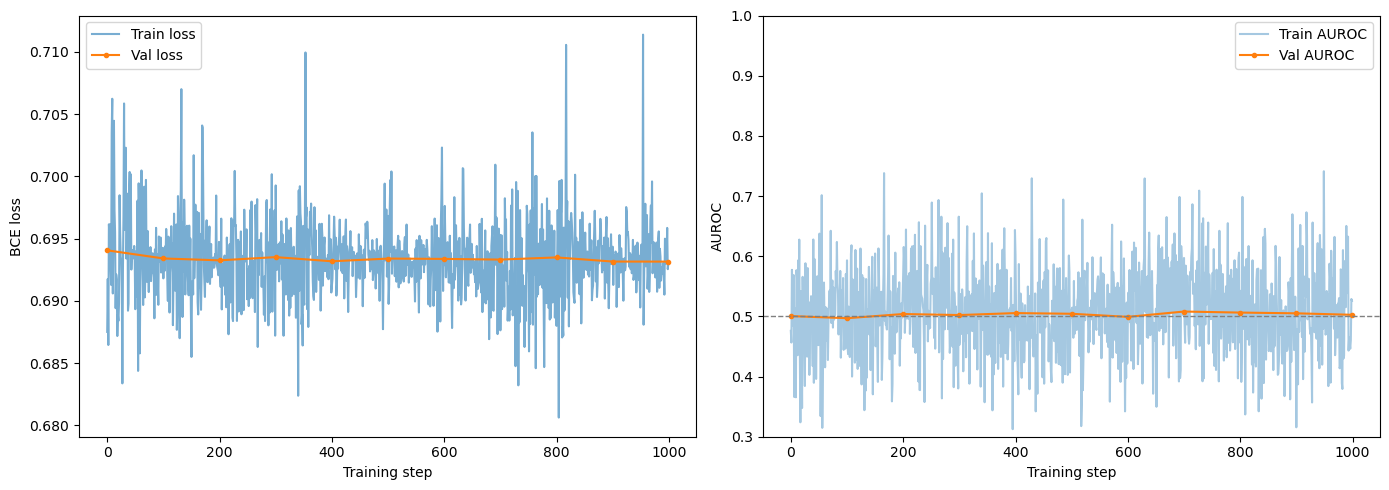

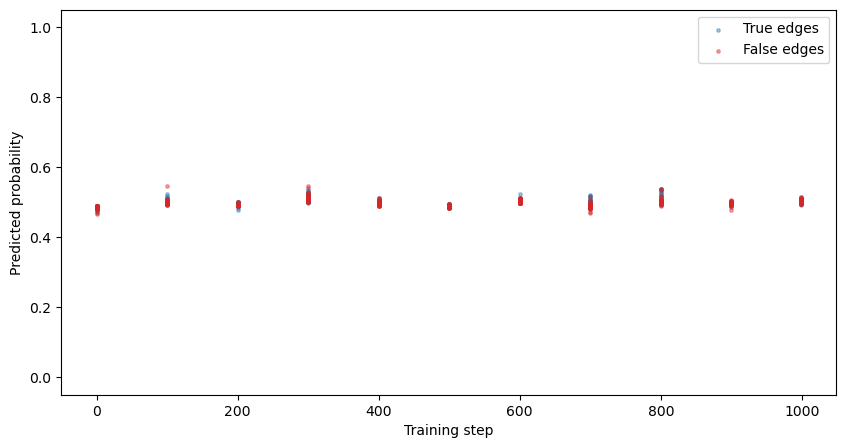

In [201]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

val = step_df[["Val loss", "Val AUROC"]].dropna()
ax1.plot(step_df.index, step_df["Train loss"], label="Train loss", alpha=0.6)
ax1.plot(val.index, val["Val loss"], label="Val loss", marker="o", ms=3)
ax1.set_xlabel("Training step"); ax1.set_ylabel("BCE loss"); ax1.legend()

ax2.plot(step_df.index, step_df["Train AUROC"], label="Train AUROC", alpha=0.4)
ax2.plot(val.index, val["Val AUROC"], label="Val AUROC", marker="o", ms=3)
ax2.axhline(0.5, color="grey", ls="--", lw=1)
ax2.set_xlabel("Training step"); ax2.set_ylabel("AUROC")
ax2.set_ylim(0.3, 1.0); ax2.legend()

plt.tight_layout(); plt.show()

# Per-edge probabilities from the detail log
plt.figure(figsize=(10, 5))
for label, colour, name in [(1, "tab:blue", "True edges"), (0, "tab:red", "False edges")]:
    subset = edge_df[edge_df["Label"] == label]
    plt.scatter(subset.index, subset["Probability"], c=colour, label=name, alpha=0.4, s=6)
plt.xlabel("Training step"); plt.ylabel("Predicted probability")
plt.ylim(-0.05, 1.05); plt.legend(); plt.show()


### Logistic Regression Baseline

In [202]:
# ==================================================================
# LOGISTIC REGRESSION BASELINE
#
# Same inputs as the network, summarized per edge. Two fits:
#   "model-matched"  -- only features the network receives
#   "plus co-expr"   -- adds TF-TG co-expression across the cell bag, which the
#                       network cannot compute: it scores each cell independently
#                       and pools afterwards, so covariance across cells never
#                       enters. If this fit beats the matched one, that gap is a
#                       missing input, not a tuning problem.
#
# Cell bags are frozen (resample_cells=False) so the table is deterministic and
# the same edge gives the same row every time.
# ==================================================================
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader

MODEL_FEATURES = [
    "bind_mean", "bind_max", "bind_sum",
    "acc_mean", "acc_frac",
    "n_peaks", "has_peaks", "absdist_min", "dist_weight_max",
    "tf_expr_mean", "tf_expr_frac", "tg_expr_mean", "tg_expr_frac",
]
COEXPR_FEATURES = ["tf_tg_spearman", "tf_tg_phi", "tf_tg_codetect"]


def _spearman(a, b):
    """Rank correlation, 0.0 when either vector is constant.

    Counts are sparse and tie-heavy, so this is weak on its own -- tf_tg_phi and
    tf_tg_codetect below measure the same idea on the binarized vectors, which
    is better behaved at this depth.
    """
    if a.std() == 0 or b.std() == 0:
        return 0.0
    return float(np.corrcoef(rankdata(a), rankdata(b))[0, 1])


def _phi(a_pos, b_pos):
    """Phi coefficient of co-detection: correlation of the two 0/1 vectors."""
    n11 = float(np.sum(a_pos & b_pos));  n10 = float(np.sum(a_pos & ~b_pos))
    n01 = float(np.sum(~a_pos & b_pos)); n00 = float(np.sum(~a_pos & ~b_pos))
    denom = np.sqrt((n11 + n10) * (n01 + n00) * (n11 + n01) * (n10 + n00))
    return 0.0 if denom == 0 else (n11 * n00 - n10 * n01) / denom


def build_feature_table(frame, binding, batch_size=64):
    """One row per edge, aligned to frame's positional order."""
    dataset = TFTGEdgeBagDataset(
        inputs=frame, resample_cells=False, seed=7,
        binding_scores=binding, **dataset_kwargs
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    rows = []
    for batch in tqdm(loader, desc="features"):
        for x in range(len(batch["label"])):
            cm = batch["cell_mask"][x].bool()
            pm = batch["peak_mask"][x].bool()
            n_peaks = int(pm.sum())

            tf_e = batch["tf_expression"][x][cm].numpy()
            tg_e = batch["tg_expression"][x][cm].numpy()
            tf_pos, tg_pos = tf_e > 0, tg_e > 0

            if n_peaks:
                acc = batch["peak_accessibility"][x][cm][:, pm].numpy()
                bind = batch["binding_score"][x][pm].numpy()
                dist = batch["peak_distance"][x][pm].abs().numpy()
                peak_stats = dict(
                    bind_mean=float(bind.mean()), bind_max=float(bind.max()),
                    bind_sum=float(bind.sum()),
                    acc_mean=float(acc.mean()), acc_frac=float((acc > 0).mean()),
                    absdist_min=float(dist.min()),
                    dist_weight_max=float(np.exp(-dist / 50_000).max()),
                )
            else:
                # Zero-fill, and let has_peaks carry "this edge had no candidates"
                # as its own term rather than hiding it in a fake zero.
                peak_stats = dict(
                    bind_mean=0.0, bind_max=0.0, bind_sum=0.0,
                    acc_mean=0.0, acc_frac=0.0,
                    absdist_min=0.0, dist_weight_max=0.0,
                )

            rows.append({
                "cell_type": batch["cell_type"][x],
                "tf_name": batch["tf_name"][x],
                "tg_id": batch["tg_id"][x],
                "label": float(batch["label"][x]),
                "n_peaks": n_peaks,
                "has_peaks": float(n_peaks > 0),
                "tf_expr_mean": float(tf_e.mean()), "tf_expr_frac": float(tf_pos.mean()),
                "tg_expr_mean": float(tg_e.mean()), "tg_expr_frac": float(tg_pos.mean()),
                "tf_tg_spearman": _spearman(tf_e, tg_e),
                "tf_tg_phi": _phi(tf_pos, tg_pos),
                "tf_tg_codetect": float(np.mean(tf_pos & tg_pos)),
                **peak_stats,
            })

    return pd.DataFrame(rows)


train_feat = build_feature_table(gt_train_df, train_binding)
val_feat = build_feature_table(gt_val_df, val_binding)
print(f"train {train_feat.shape}, val {val_feat.shape}")

def auroc_ci(scores, labels):
    """AUROC with a Hanley-McNeil 95% interval. Report the interval always --
    the within-TG subsets here are small enough that a bare AUROC misleads."""
    scores, labels = np.asarray(scores, float), np.asarray(labels, float)
    keep = ~np.isnan(scores)
    scores, labels = scores[keep], labels[keep]
    npos, nneg = int(labels.sum()), int((1 - labels).sum())
    if npos < 1 or nneg < 1:
        return np.nan, np.nan
    order = np.argsort(scores); ranks = np.empty(len(scores)); ranks[order] = np.arange(1, len(scores) + 1)
    a = (ranks[labels == 1].sum() - npos * (npos + 1) / 2) / (npos * nneg)
    q1, q2 = a / (2 - a), 2 * a**2 / (1 + a)
    var = (a * (1 - a) + (npos - 1) * (q1 - a**2) + (nneg - 1) * (q2 - a**2)) / (npos * nneg)
    return a, 1.96 * np.sqrt(max(var, 0))


def within_tg_auroc(frame, scores):
    """AUROC after removing each target gene's mean score.

    This is the headline metric: TG-level features are constant across the TFs
    paired with a gene, so they cannot resolve an edge. Only target genes carrying
    both labels contribute.
    """
    df = frame.assign(score=scores)
    mixed = df.groupby("tg_id")["label"].nunique().eq(2)
    df = df[df["tg_id"].isin(mixed[mixed].index)]
    if len(df) < 10:
        return np.nan, np.nan, 0
    centered = df["score"] - df.groupby("tg_id")["score"].transform("mean")
    a, ci = auroc_ci(centered, df["label"])
    return a, ci, len(df)


fits = {
    "model-matched": MODEL_FEATURES,
    "plus co-expr": MODEL_FEATURES + COEXPR_FEATURES,
}

results = {}
for name, cols in fits.items():
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, C=1.0),
    )
    pipe.fit(train_feat[cols], train_feat["label"])
    val_scores = pipe.predict_proba(val_feat[cols])[:, 1]
    results[name] = (pipe, cols, val_scores)

    raw, raw_ci = auroc_ci(val_scores, val_feat["label"])
    wtg, wtg_ci, n_wtg = within_tg_auroc(val_feat, val_scores)
    tr, _ = auroc_ci(pipe.predict_proba(train_feat[cols])[:, 1], train_feat["label"])

    print(f"\n=== {name} ({len(cols)} features) ===")
    print(f"  train AUROC     {tr:.3f}")
    print(f"  val   AUROC     {raw:.3f} +/- {raw_ci:.3f}")
    print(f"  val   within-TG {wtg:.3f} +/- {wtg_ci:.3f}   (n={n_wtg})")

    coefs = pd.Series(pipe[-1].coef_[0], index=cols).sort_values(key=abs, ascending=False)
    print("  coefficients (standardized):")
    print(coefs.round(3).to_string().replace("\n", "\n    "))

print("\n=== single features on val ===")
for c in MODEL_FEATURES + COEXPR_FEATURES:
    a, ci = auroc_ci(val_feat[c], val_feat["label"])
    w, _, _ = within_tg_auroc(val_feat, val_feat[c])
    print(f"  {c:18s} raw {a:.3f} +/- {ci:.3f}    within-TG {w:.3f}")

print("\n=== per slice, plus co-expr fit ===")
_, cols, val_scores = results["plus co-expr"]
for slice_name, idx in val_feat.groupby("cell_type").groups.items():
    sub = val_feat.loc[idx]
    a, ci = auroc_ci(val_scores[val_feat.index.get_indexer(idx)], sub["label"])
    w, _, n = within_tg_auroc(sub, val_scores[val_feat.index.get_indexer(idx)])
    print(f"  {slice_name:32s} n={len(sub):5,}  raw {a:.3f} +/- {ci:.3f}   within-TG {w:.3f} (n={n})")



features: 100%|█████████████████████████████████| 38/38 [00:05<00:00,  6.96it/s]


train (29708, 20), val (2404, 20)

=== model-matched (13 features) ===
  train AUROC     0.514
  val   AUROC     0.499 +/- 0.023
  val   within-TG 0.503 +/- 0.023   (n=2404)
  coefficients (standardized):
bind_max           0.080
    bind_mean         -0.035
    n_peaks           -0.024
    bind_sum           0.013
    has_peaks         -0.007
    acc_frac          -0.006
    tf_expr_frac       0.006
    tg_expr_frac       0.005
    tg_expr_mean      -0.005
    tf_expr_mean       0.002
    acc_mean           0.002
    absdist_min        0.001
    dist_weight_max    0.000

=== plus co-expr (16 features) ===
  train AUROC     0.517
  val   AUROC     0.502 +/- 0.023
  val   within-TG 0.506 +/- 0.023   (n=2404)
  coefficients (standardized):
bind_max           0.079
    tf_tg_phi          0.037
    bind_mean         -0.035
    n_peaks           -0.024
    tf_tg_spearman    -0.018
    tg_expr_frac       0.018
    tf_tg_codetect    -0.017
    bind_sum           0.013
    tf_expr_frac       0

In [203]:
def eta_squared(values, groups):
    """Fraction of a feature's variance explained by a grouping.

    tf_expr_mean is a property of the TF, and binding is mostly a per-TF constant,
    so both must be strongly explained by tf_name. Near zero means the feature
    table rows do not correspond to the frame rows they were built from.
    """
    df = pd.DataFrame({"v": np.asarray(values, float), "g": np.asarray(groups)})
    total = df["v"].var(ddof=0)
    if total == 0:
        return np.nan
    within = df.groupby("g")["v"].transform("mean")
    return float(within.var(ddof=0) / total)

for col in ["tf_expr_mean", "tf_expr_frac", "bind_mean", "bind_max"]:
    print(f"{col:14s} eta^2 by TF {eta_squared(train_feat[col], train_feat['tf_name']):.3f}")
for col in ["tg_expr_mean", "n_peaks", "absdist_min", "acc_mean"]:
    print(f"{col:14s} eta^2 by TG {eta_squared(train_feat[col], train_feat['tg_id']):.3f}")

rng = np.random.default_rng(0)
planted = (train_feat["bind_max"] > train_feat["bind_max"].median()).astype(float)
flip = rng.random(len(planted)) < 0.20          # 20% label noise
planted = np.where(flip, 1 - planted, planted)

pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
pipe.fit(train_feat[MODEL_FEATURES], planted)
print("planted-label train AUROC: %.3f" % auroc_ci(
    pipe.predict_proba(train_feat[MODEL_FEATURES])[:, 1], planted)[0])


tf_expr_mean   eta^2 by TF 0.893
tf_expr_frac   eta^2 by TF 0.852
bind_mean      eta^2 by TF 0.503
bind_max       eta^2 by TF 0.452
tg_expr_mean   eta^2 by TG 0.671
n_peaks        eta^2 by TG 1.000
absdist_min    eta^2 by TG 1.000
acc_mean       eta^2 by TG 0.818
planted-label train AUROC: 0.799


### Training parameter sweep

In [ ]:
# ==================================================================
# SWEEP HARNESS
# Wraps the training loop so a config dict drives it, and reports
# within-TG val AUROC -- the headline metric -- not just raw AUROC.
# ==================================================================

# Global normalization constants, computed once from the train split so a run's
# scaling does not depend on its own batches.
_norm_stats = {}
def _fit_norm_stats():
    probe = DataLoader(
        TFTGEdgeBagDataset(inputs=gt_train_df, resample_cells=False, seed=7,
                           binding_scores=train_binding, **dataset_kwargs),
        batch_size=256, shuffle=False, num_workers=0,
    )
    acc = {k: [] for k in ("tf_expression", "tg_expression", "peak_accessibility")}
    for i, batch in enumerate(probe):
        for k in acc:
            acc[k].append(torch.log1p(batch[k]).flatten())
        if i >= 8:          # a few hundred edges is plenty for a mean and a sd
            break
    for k, parts in acc.items():
        v = torch.cat(parts)
        _norm_stats[k] = (float(v.mean()), float(v.std()) or 1.0)
    print("log1p stats:", {k: (round(m, 3), round(s, 3)) for k, (m, s) in _norm_stats.items()})

_fit_norm_stats()


def normalize_batch(mb, mode):
    """Raw counts are mostly zero with a few large values, so nn.Linear(1, d)
    sees a near-constant input plus a handful of outliers. log1p compresses the
    tail; standardizing puts it in the range the SiLU actually bends in."""
    if mode == "none":
        return mb
    for k in ("tf_expression", "tg_expression", "peak_accessibility"):
        v = torch.log1p(mb[k])
        if mode == "log1p_std":
            m, s = _norm_stats[k]
            v = (v - m) / s
        mb[k] = v
    return mb


@torch.no_grad()
def evaluate_full(model, loader, frame, cfg):
    """Raw and within-TG AUROC over an entire split."""
    model.eval()
    logits, loss_sum, n = [], 0.0, 0
    for batch in loader:
        mb = {k: batch[k].to(device) for k in gpu_keys}
        mb = normalize_batch(mb, cfg["norm"])
        edge_logits, _ = model(mb, pooling_temperature=cfg["temperature"])
        loss_sum += float(nn.functional.binary_cross_entropy_with_logits(
            edge_logits, mb["label"].float(), reduction="sum"))
        n += len(edge_logits)
        logits.append(edge_logits.cpu())
    model.train()

    scores = torch.cat(logits).numpy()
    raw, _ = auroc_ci(scores, frame["label"].to_numpy(float))
    wtg, _, n_wtg = within_tg_auroc(
        frame.rename(columns={"tg_id": "tg_id"}), scores
    )
    return dict(val_loss=loss_sum / n, val_auroc=raw, val_within_tg=wtg, n_within_tg=n_wtg)


def run_experiment(cfg):
    torch.manual_seed(cfg["seed"])
    np.random.seed(cfg["seed"])

    train_ds = TFTGEdgeBagDataset(
        inputs=gt_train_df, resample_cells=cfg["resample_cells"], seed=42,
        binding_scores=train_binding, **dataset_kwargs)
    val_ds = TFTGEdgeBagDataset(
        inputs=gt_val_df, resample_cells=False, seed=7,
        binding_scores=val_binding, **dataset_kwargs)

    tl = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True,
                    num_workers=0, drop_last=True)
    vl = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=0)

    m = SimpleTFTGRegulationModel(
        pretrained_tf_peak_model=trained_tf_peak_model,
        d_model=cfg["d_model"], num_heads=4, dropout=cfg["dropout"],
    ).to(device)

    opt = torch.optim.AdamW(
        [p for p in m.parameters() if p.requires_grad],
        lr=cfg["lr"], weight_decay=cfg["weight_decay"])

    batches, history = infinite(tl), []
    m.train()
    for step in range(cfg["steps"]):
        opt.zero_grad(set_to_none=True)
        batch = next(batches)
        mb = {k: batch[k].to(device) for k in gpu_keys}
        mb = normalize_batch(mb, cfg["norm"])

        edge_logits, _ = m(mb, pooling_temperature=cfg["temperature"])
        loss = nn.functional.binary_cross_entropy_with_logits(
            edge_logits, mb["label"].float())
        loss.backward()
        if cfg["clip"]:
            torch.nn.utils.clip_grad_norm_(m.parameters(), cfg["clip"])
        opt.step()

        if (step + 1) % cfg["eval_every"] == 0:
            history.append({"step": step + 1, **evaluate_full(m, vl, gt_val_df, cfg)})

    final = history[-1]
    # Spread is the collapse detector: a model emitting one number has a
    # meaningless AUROC, however that AUROC happens to land.
    with torch.no_grad():
        probe = next(infinite(vl))
        mb = normalize_batch({k: probe[k].to(device) for k in gpu_keys}, cfg["norm"])
        spread = float(m(mb, pooling_temperature=cfg["temperature"])[0].sigmoid().std())

    return {**final, "prob_std": spread, "history": history, "model": m}


BASE = dict(seed=0, steps=2000, batch_size=64, lr=1e-4, weight_decay=1e-4,
            d_model=128, dropout=0.0, norm="none", temperature=1.0,
            resample_cells=True, clip=None, eval_every=250)


In [ ]:
VARIANTS = {
    "baseline":        {},
    "log1p":           dict(norm="log1p"),
    "log1p_std":       dict(norm="log1p_std"),
    "temp4":           dict(temperature=4.0),
    "temp16":          dict(temperature=16.0),
    "lr1e-3":          dict(lr=1e-3),
    "lr3e-3":          dict(lr=3e-3),
    "no_wd":           dict(weight_decay=0.0),
    "frozen_cells":    dict(resample_cells=False),
    "frozen+log1p":    dict(resample_cells=False, norm="log1p_std"),
    "long":            dict(steps=10000),
    "clip1":           dict(clip=1.0),
    "batch256":        dict(batch_size=256),
    "wide":            dict(d_model=256),
    "combo":           dict(norm="log1p_std", temperature=8.0, lr=1e-3, weight_decay=0.0),
}

rows = []
for name, override in VARIANTS.items():
    cfg = {**BASE, **override}
    out = run_experiment(cfg)
    rows.append({"variant": name, "val_auroc": out["val_auroc"],
                 "within_tg": out["val_within_tg"], "val_loss": out["val_loss"],
                 "prob_std": out["prob_std"], "steps": cfg["steps"]})
    print(f"{name:16s} AUROC {out['val_auroc']:.3f}  within-TG {out['val_within_tg']:.3f}  "
          f"loss {out['val_loss']:.5f}  spread {out['prob_std']:.4f}")

sweep = pd.DataFrame(rows).sort_values("within_tg", ascending=False)
display(sweep.round(4))
sweep.to_csv(PROJECT_DIR / "sweep_results.csv", index=False)
